In [4]:
# best models: offline random forest / or combine random forest
import numpy as np
from national.data_refresh.src import utils
import matplotlib as mpl
from national.data_refresh.src import params
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None

def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    for conti in ['Asia', 'Africa', 'Europe', 'South America', 'North America', 'Oceania']:
        if f'conti_{conti}' not in data.columns.tolist():
            data[f'conti_{conti}'] = [0]*len(data)
    return data

In [5]:
fb_cols = params.fb_vars
bg_cols = params.bg_cols
model_specs = {'online': fb_cols+['conti'], 'offline': bg_cols, 'combined': fb_cols + bg_cols}


# compare the gaps computed directly and from levels


## the original model


In [4]:
# read data and set up the plot

df_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:


    for outcome_var in ['wom', 'men', 'ggi']:

        data_path = params.dropbox_data_path / f"combined_data/{indicator}"
        dataset = "combined_multiple_years_no_missing_fb_aligned.csv"
        df = pd.read_csv(data_path / dataset)
        df = df.dropna(subset=params.bg_cols+params.fb_vars)
        df_to_predict = df.loc[df[f'{indicator}_{outcome_var}'].notnull()]

        model_filename = f'{indicator}_combined_{indicator}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / 'models/rf_del_countries' / model_filename

        # load the model
        model = load_model(model_filepath)
        df_predict_results = pd.DataFrame(columns=['outcome_var','model_type','iso3', 'year', 'true', 'pred'])

        X = preprocess_data(df_to_predict[model_specs['combined']])
        countries = df_to_predict['iso3'].tolist()
        years = df_to_predict[f'{indicator}_year'].tolist()
        true_values = df_to_predict[f'{indicator}_{outcome_var}'].tolist()
        y_pred = model.predict(X)

        for ind in range(len(y_pred)):
            df_predict_results.loc[len(df_predict_results), :] = [f'{indicator}_{outcome_var}','combined',countries[ind], years[ind], true_values[ind], y_pred[ind]]

        df_res = pd.concat([df_res, df_predict_results], axis=0)

    # df_res.drop(columns=['year'], inplace=True)
    # df_res.rename(columns={f'{indicator}_year': 'year'}, inplace=True)
# df_res.to_csv(params.dropbox_data_path.parent/'results/random_forest_most_recent_aligned_results.csv', index=False)

In [5]:
# prepare the df_compare
df_res['indicator']=df_res['outcome_var'].apply(lambda x: x.split('_')[0])
df_res['outcome_type']=df_res['outcome_var'].apply(lambda x: x.split('_')[1])

df_compare = pd.DataFrame()
for var_name,group in df_res.groupby(['indicator']):

    temp = group.loc[group['outcome_type']=='ggi']
    temp['computed_ratio_true'] = group.loc[group['outcome_type']=='wom']['true']/group.loc[group['outcome_type']=='men']['true']
    temp['computed_ratio_pred'] = group.loc[group['outcome_type']=='wom']['pred']/group.loc[group['outcome_type']=='men']['pred']

    df_compare = pd.concat([df_compare, temp], axis=0)

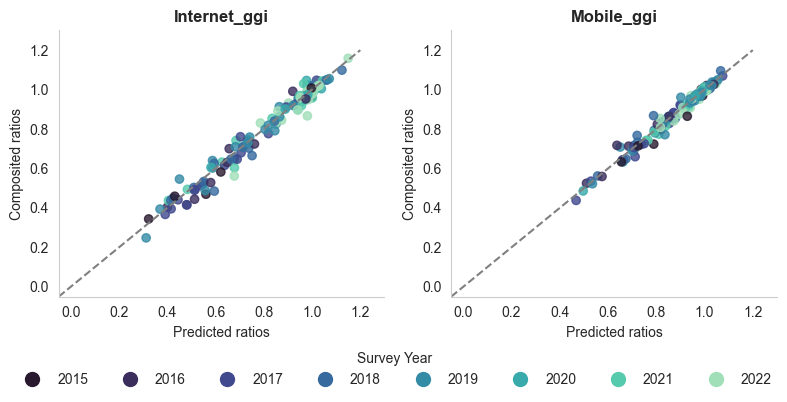

In [6]:

# Plot the distribution of the differences
years = sorted(df_res['year'].unique())
palette = sns.color_palette("mako", len(years))
#colors = params.colors
#year_color_map = {year:colors for year,colors in zip(years,colors.values())}
year_color_map = dict(zip(years, palette))


x_min = -0.05
y_max = 1.3
fig, axs = plt.subplots(1,2, figsize=(8, 4))  # 2 rows for 'internet' and 'mobile', 3 columns for 'ggi', 'men', 'wom'
axs = axs.flatten()
for row, indicator in enumerate(['internet', 'mobile']):


    df_diff = df_compare.loc[df_compare['outcome_var'] == f'{indicator}_ggi']

    scatter = axs[row].scatter(df_diff['computed_ratio_pred'], df_diff['pred'], c=df_diff['year'].map(year_color_map), alpha=0.8)

    axs[row].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")

    axs[row].set_title(f'{indicator.capitalize()}_ggi', fontweight='bold')
    axs[row].set_xlabel(f'Predicted ratios')
    axs[row].set_ylabel('Composited ratios')
    x_min = -0.05
    y_max = 1.3
    axs[row].set_xlim(x_min, y_max)
    axs[row].set_ylim(x_min, y_max)

    for spine in ['top', 'right']:
        axs[row].spines[spine].set_visible(False)
    axs[row].grid(axis='both', linestyle='--', alpha=0)

n_cols = len(years)
import matplotlib.lines as mlines

# Define the legend with dots instead of rectangles
legend_elements = [mlines.Line2D([], [], color=year_color_map[year], marker='o', linestyle='None', markersize=10, label=str(round(year))) for year in years]

# Add the shared legend for both rows
fig.legend(handles=legend_elements, loc='lower center', ncol=n_cols, title='Survey Year', bbox_to_anchor=(0.5, -0.01), frameon=False)

fig.tight_layout(rect=[0, 0.1, 1, 1])

# Save the plot as a PDF
# plt.show()

# plt.savefig(params.dropbox_data_path.parent / 'graphs/result_check/predicted_ratio_and_composite_ratio_compare_most_recent.pdf')


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines


years = sorted(df_res['year'].unique())
palette = sns.color_palette("mako", len(years))
year_color_map = dict(zip(years, palette))

x_min = -0.05
y_max = 1.3



# Create subplots for 2x2: 'pred vs true' and 'computed_ratio_pred vs true'
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

# Loop over indicators and plot both comparisons for each
for row, indicator in enumerate(['internet', 'mobile']):

    # Plot: pred vs true
    df_diff = df_compare.loc[df_compare['outcome_var'] == f'{indicator}_ggi']
    df_diff['diff_pred'] = df_diff['true'] - df_diff['pred']
    df_diff['diff_computed_ratio_pred'] = df_diff['true'] - df_diff['computed_ratio_pred']
    df_diff['diff_pred']=df_diff['diff_pred'].astype(float).abs()
    df_diff['diff_computed_ratio_pred']=df_diff['diff_computed_ratio_pred'].astype(float).abs()

    # Plot 1: Predicted ratios vs True values
    scatter1 = axs[row*2].scatter(df_diff['pred'], df_diff['true'], c=df_diff['year'].map(year_color_map), alpha=0.8)
    axs[row*2].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
    axs[row*2].set_title(f'{indicator.capitalize()} GGI: True vs Pred', fontweight='bold')
    axs[row*2].set_xlabel(f'Predicted ratios')
    axs[row*2].set_ylabel('True ratios')
    axs[row*2].set_xlim(x_min, y_max)
    axs[row*2].set_ylim(x_min, y_max)
    axs[row*2].grid(axis='both', linestyle='--', alpha=0.5)
    # mark r2 and MAE
    r_2 = r2_score(df_diff['true'], df_diff['pred'])
    MAE = mean_absolute_error(df_diff['true'], df_diff['pred'])
    axs[row*2].text(0.85, 0.15, f'R2: {r_2:.3f}\nMAE: {MAE:.3f}', transform=axs[row*2].transAxes, fontsize=10)

    # Mark the top 3 differences in 'diff_pred'
    top3_pred_diff = df_diff.nlargest(3, 'diff_pred')
    for i, row_data in top3_pred_diff.iterrows():
        axs[row*2].annotate(row_data['iso3'], (row_data['pred'], row_data['true']),
                            textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8, color='red')


    # Plot 2: Computed_ratio_pred vs True values
    scatter2 = axs[row*2 + 1].scatter(df_diff['computed_ratio_pred'], df_diff['true'], c=df_diff['year'].map(year_color_map), alpha=0.8)
    axs[row*2 + 1].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
    axs[row*2 + 1].set_title(f'{indicator.capitalize()} GGI: True vs Computed Ratio ', fontweight='bold')
    axs[row*2 + 1].set_xlabel(f'Computed ratios')
    axs[row*2 + 1].set_ylabel('True ratios')
    axs[row*2 + 1].set_xlim(x_min, y_max)
    axs[row*2 + 1].set_ylim(x_min, y_max)
    axs[row*2 + 1].grid(axis='both', linestyle='--', alpha=0.5)
    r_2 = r2_score(df_diff['true'], df_diff['computed_ratio_pred'])
    MAE = mean_absolute_error(df_diff['true'], df_diff['computed_ratio_pred'])
    axs[row*2 + 1].text(0.85, 0.15, f'R2: {r_2:.3f}\nMAE: {MAE:.3f}', transform=axs[row*2+1].transAxes, fontsize=10)

    # Mark the top 3 differences in 'diff_computed_ratio_pred'
    top3_computed_diff = df_diff.nlargest(3, 'diff_computed_ratio_pred')
    for i, row_data in top3_computed_diff.iterrows():
        axs[row*2 + 1].annotate(row_data['iso3'], (row_data['computed_ratio_pred'], row_data['true']),
                                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8, color='blue')


    # Set visual aesthetics
    for spine in ['top', 'right']:
        axs[row*2].spines[spine].set_visible(False)
        axs[row*2 + 1].spines[spine].set_visible(False)

# Legend for the years
legend_elements = [mlines.Line2D([], [], color=year_color_map[year], marker='o', linestyle='None', markersize=10, label=str(round(year))) for year in years]
fig.legend(handles=legend_elements, loc='lower center', ncol=len(years), title='Survey Year', bbox_to_anchor=(0.5, 0.05), frameon=False)

# Adjust layout to prevent overlap
fig.tight_layout(rect=[0, 0.1, 1, 1])
fig.suptitle('True ratios vs pred (computed) ratio, from most recently aligned data', fontsize=12, fontweight='bold')
# Save the plot or display it
# plt.savefig('pred_vs_true_and_computed_ratio_vs_true.pdf')
plt.show()


## results from yearly aligned data

In [9]:
# import data
files = [x for x in os.listdir(params.dropbox_data_path.parent / 'results/pred_by_year_data') if '.csv' in x]
df_res = pd.DataFrame()
for file in files:
    temp = pd.read_csv(params.dropbox_data_path.parent / 'results/pred_by_year_data' / file)
    df_res = pd.concat([df_res, temp], axis=0)


In [10]:
# prepare the df_compare
df_compare = pd.DataFrame()
for var_name,group in df_res.groupby(['indicator']):
    for year in group['year'].unique():
        temp = group.loc[(group['year']==year )& (group['outcome_var']=='ggi')]
        for iso3 in temp['iso3'].unique():
            temp_iso3 = group.loc[(group['year']==year)&(group['iso3']==iso3)]

            temp.loc[temp['iso3']==iso3,'computed_ratio_pred'] = temp_iso3.loc[temp_iso3['outcome_var']=='wom']['pred']/temp_iso3.loc[temp_iso3['outcome_var']=='men']['pred']


        df_compare = pd.concat([df_compare, temp], axis=0)
df_compare['ratio'] = df_compare['computed_ratio_pred']/df_compare['pred']

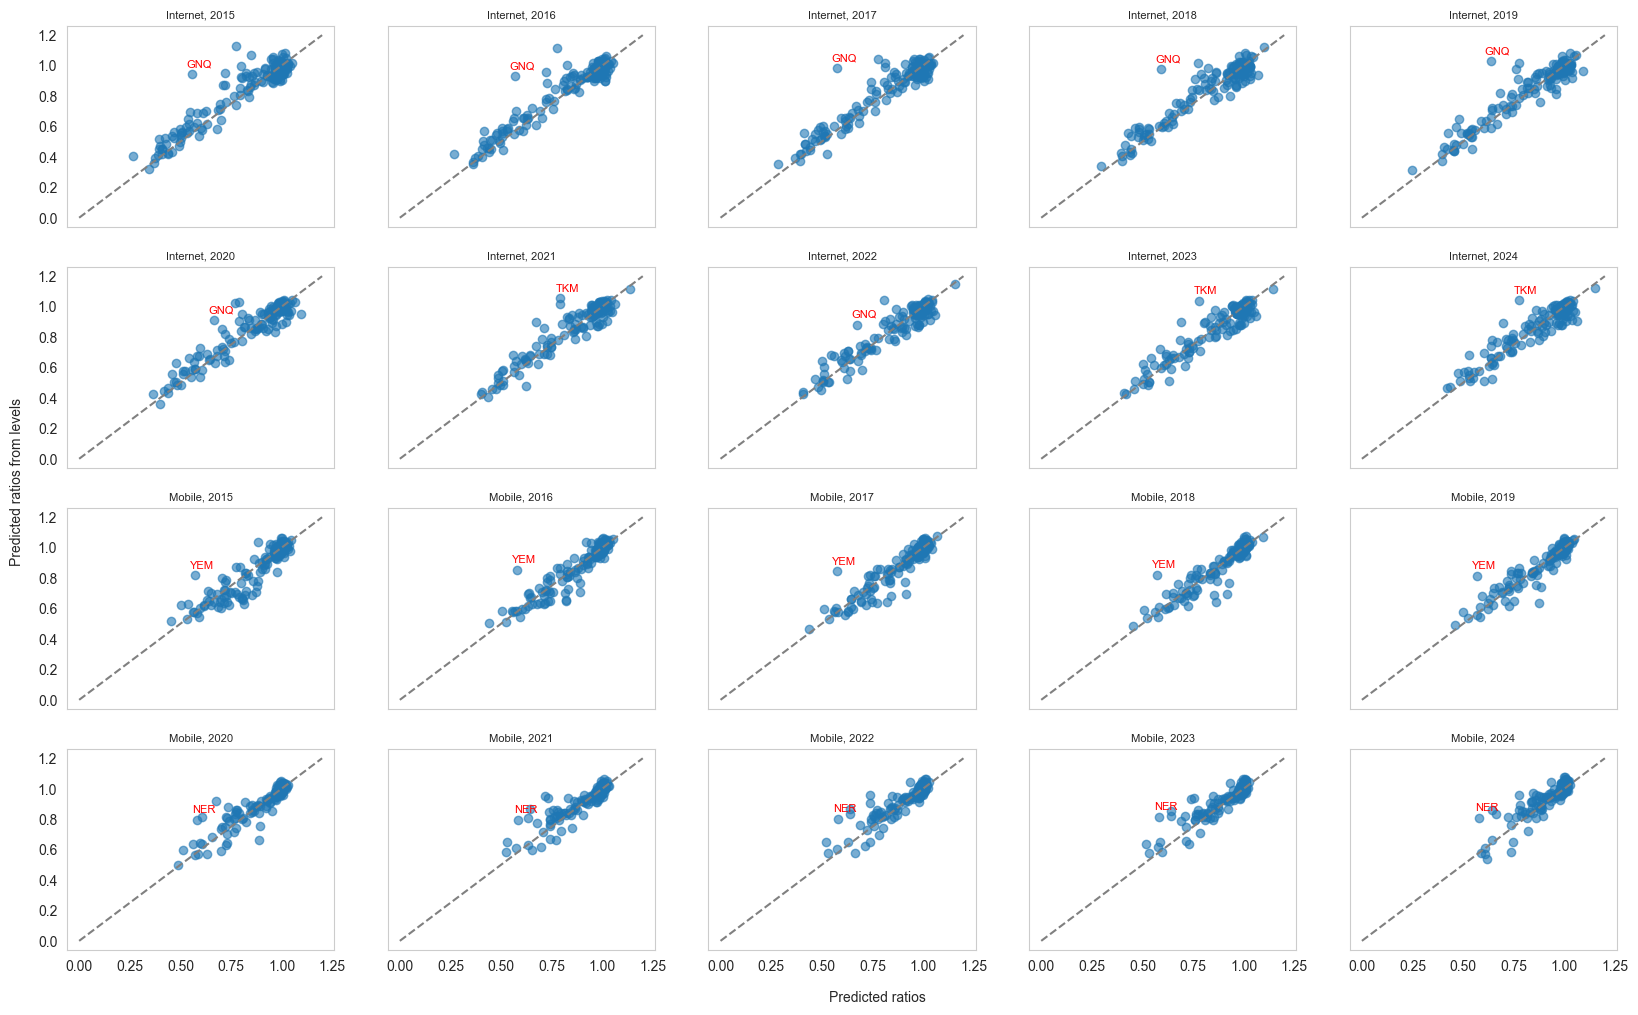

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get unique indicators and years
unique_indicators = df_compare['indicator'].unique()  # Replace 'indicator' with the actual column name
unique_years = df_compare['year'].unique()  # Replace 'year' with the actual column name

# Define the number of columns per row
n_cols = 5
# Calculate number of rows needed based on the number of subplots (indicators * years)
n_subplots = len(unique_indicators) * len(unique_years)
n_rows = (n_subplots // n_cols) + (n_subplots % n_cols > 0)

# Step 2: Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten axes to easily iterate through them

# Step 3: Iterate over each unique indicator and year to create scatter plots in subplots
plot_idx = 0
for indicator in unique_indicators:
    for year in unique_years:
        # Filter the data for the current indicator and year
        filtered_data = df_compare[(df_compare['indicator'] == indicator) & (df_compare['year'] == year)]

        # Plot if there's data for this combination
        if not filtered_data.empty:
            ax = axes[plot_idx]  # Access the specific subplot
            ax.scatter(filtered_data['pred'], filtered_data['computed_ratio_pred'], alpha=0.6)

            # Mark the point with the max value in 'ratio'
            max_idx = filtered_data['ratio'].idxmax()  # Get the index of the max 'ratio' value
            max_value = filtered_data.loc[max_idx]  # Get the row with the max 'ratio' value
            ax.annotate(
                max_value['iso3'],
                (max_value['pred'], max_value['computed_ratio_pred']),
                textcoords="offset points",
                xytext=(5, 5),
                ha='center',
                fontsize=8,
                color='red'
            )

            # Plot the 45-degree reference line
            ax.plot([0, 1.2], [0, 1.2], ls="--", c="grey")

            # Set the title
            ax.set_title(f'{indicator.capitalize()}, {round(year)}', fontsize=8)
            ax.grid(axis='both', linestyle='--', alpha=0)

            plot_idx += 1

# Set common labels
fig.text(0.53, 0.07, 'Predicted ratios', ha='center', va='center')
fig.text(0.1, 0.5, 'Predicted ratios from levels', ha='center', va='center', rotation='vertical')

# plt.savefig(params.dropbox_data_path.parent / 'graphs/result_check/predicted_ratio_and_computed_ratio_compare_yearly_aligned.pdf')

plt.show()


## plot of true vs predicted values in the yearly aligned data (all years together)

In [12]:
df_compare = df_compare.dropna(subset=['true'])

df_compare['diff_pred'] = df_compare['true'] - df_compare['pred']
df_compare['diff_computed_ratio_pred'] = df_compare['true'] - df_compare['computed_ratio_pred']
df_compare['diff_pred']=df_compare['diff_pred'].astype(float).abs()
df_compare['diff_computed_ratio_pred']=df_compare['diff_computed_ratio_pred'].astype(float).abs()


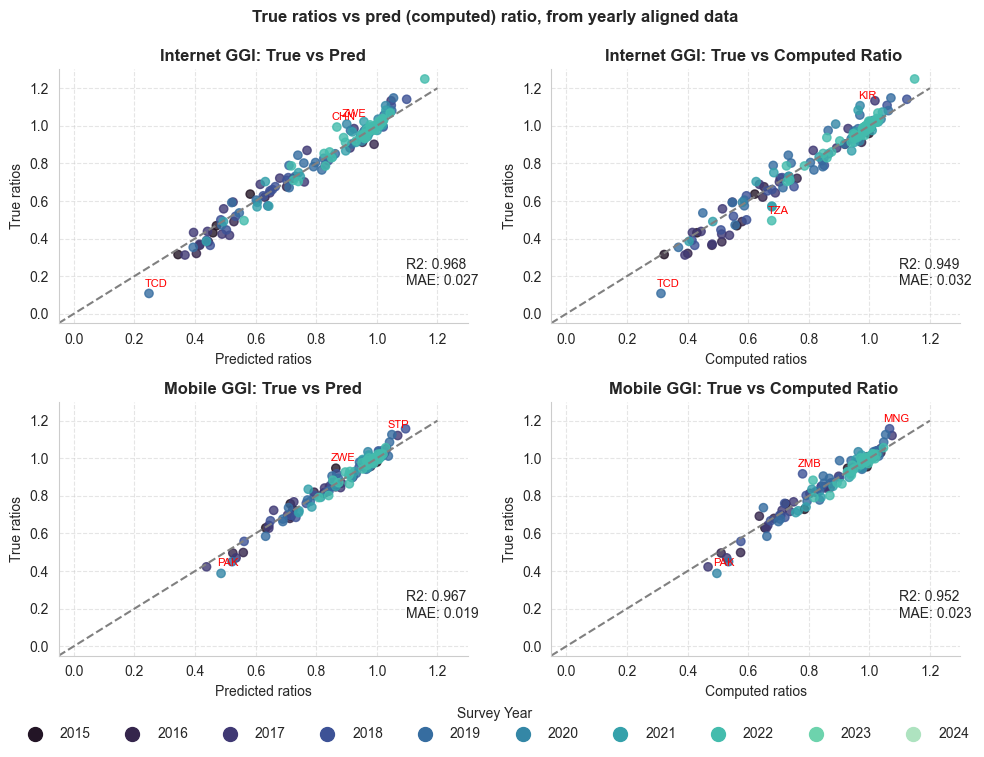

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines


years = sorted(df_res['year'].unique())
palette = sns.color_palette("mako", len(years))
year_color_map = dict(zip(years, palette))

x_min = -0.05
y_max = 1.3



# Create subplots for 2x2: 'pred vs true' and 'computed_ratio_pred vs true'
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

# Loop over indicators and plot both comparisons for each
for row, indicator in enumerate(['internet', 'mobile']):

    # Plot: pred vs true
    df_diff = df_compare.loc[df_compare['indicator'] == f'{indicator}']
    df_diff['diff_pred'] = df_diff['true'] - df_diff['pred']
    df_diff['diff_computed_ratio_pred'] = df_diff['true'] - df_diff['computed_ratio_pred']
    df_diff['diff_pred']=df_diff['diff_pred'].astype(float).abs()
    df_diff['diff_computed_ratio_pred']=df_diff['diff_computed_ratio_pred'].astype(float).abs()

    # Plot 1: Predicted ratios vs True values
    scatter1 = axs[row*2].scatter(df_diff['pred'], df_diff['true'], c=df_diff['year'].map(year_color_map), alpha=0.8)
    axs[row*2].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
    axs[row*2].set_title(f'{indicator.capitalize()} GGI: True vs Pred', fontweight='bold')
    axs[row*2].set_xlabel(f'Predicted ratios')
    axs[row*2].set_ylabel('True ratios')
    axs[row*2].set_xlim(x_min, y_max)
    axs[row*2].set_ylim(x_min, y_max)
    axs[row*2].grid(axis='both', linestyle='--', alpha=0.5)
    # mark r2 and MAE
    r_2 = r2_score(df_diff['true'], df_diff['pred'])
    MAE = mean_absolute_error(df_diff['true'], df_diff['pred'])
    axs[row*2].text(0.85, 0.15, f'R2: {r_2:.3f}\nMAE: {MAE:.3f}', transform=axs[row*2].transAxes, fontsize=10)

    # Mark the top 3 differences in 'diff_pred'
    top3_pred_diff = df_diff.nlargest(3, 'diff_pred')
    for i, row_data in top3_pred_diff.iterrows():
        axs[row*2].annotate(row_data['iso3'], (row_data['pred'], row_data['true']),
                            textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8, color='red')


    # Plot 2: Computed_ratio_pred vs True values
    scatter2 = axs[row*2 + 1].scatter(df_diff['computed_ratio_pred'], df_diff['true'], c=df_diff['year'].map(year_color_map), alpha=0.8)
    axs[row*2 + 1].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
    axs[row*2 + 1].set_title(f'{indicator.capitalize()} GGI: True vs Computed Ratio ', fontweight='bold')
    axs[row*2 + 1].set_xlabel(f'Computed ratios')
    axs[row*2 + 1].set_ylabel('True ratios')
    axs[row*2 + 1].set_xlim(x_min, y_max)
    axs[row*2 + 1].set_ylim(x_min, y_max)
    axs[row*2 + 1].grid(axis='both', linestyle='--', alpha=0.5)
    r_2 = r2_score(df_diff['true'], df_diff['computed_ratio_pred'])
    MAE = mean_absolute_error(df_diff['true'], df_diff['computed_ratio_pred'])
    axs[row*2 + 1].text(0.85, 0.15, f'R2: {r_2:.3f}\nMAE: {MAE:.3f}', transform=axs[row*2+1].transAxes, fontsize=10)

    # Mark the top 3 differences in 'diff_computed_ratio_pred'
    top3_computed_diff = df_diff.nlargest(3, 'diff_computed_ratio_pred')
    for i, row_data in top3_computed_diff.iterrows():
        axs[row*2 + 1].annotate(row_data['iso3'], (row_data['computed_ratio_pred'], row_data['true']),
                                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8, color='red')


    # Set visual aesthetics
    for spine in ['top', 'right']:
        axs[row*2].spines[spine].set_visible(False)
        axs[row*2 + 1].spines[spine].set_visible(False)

# Legend for the years
legend_elements = [mlines.Line2D([], [], color=year_color_map[year], marker='o', linestyle='None', markersize=10, label=str(round(year))) for year in years]
fig.legend(handles=legend_elements, loc='lower center', ncol=len(years), title='Survey Year', bbox_to_anchor=(0.5, 0.05), frameon=False)

# Adjust layout to prevent overlap
fig.tight_layout(rect=[0, 0.1, 1, 0.95])
fig.suptitle('True ratios vs pred (computed) ratio, from yearly aligned data', fontsize=12, fontweight='bold')

# Save the plot or display it
plt.savefig(params.dropbox_data_path.parent / 'graphs/result_check/True_ratios_vs_pred_(computed)_ratio_yearly_aligned.pdf')
plt.show()


# GSMA comparisons

As most of the reports in the GSMA are about the LMIC, we will firstly define the LIMC in the result files (only on the yearly aligned data) and then compare the results from the GSMA reports with the results from the models.

key findings from GMSA:

1. Women’s rate of mobile internet adoption increased over the past year across low- and middle-income countries. There are now more women using mobile internet
in these countries than ever before: 66% (1.5 billion). By comparison, 78% of men now use mobile internet, but their rate of adoption slowed in 2023.

2. The gender gap in mobile internet adoption across low- and middle-income countries has narrowed for the first time since 2020 due to women adopting it at a faster rate than men. This reduction was driven primarily by South Asia and brings the overall mobile internet gender gap back to where it was in 2020. This gender gap also narrowed slightly in Sub- Saharan Africa for the first time in five years.

3. Women are now 15% less likely than men to use mobile internet across low- and middle- income countries. This translates to around 265 million fewer women than men.

4. Of the 785 million women who are still not using mobile internet in low-and middle- income countries, around 60% live in South Asia and Sub-Saharan Africa. Women in these regions are still the least likely to use mobile internet compared to men, with gender gaps of 31% and 32%, respectively.
5. The gender gap in smartphone ownership across low- and middle-income countries has narrowed slightly from 15% to 13% over the past year. This translates to around 200 million fewer women than men who own one. In these countries, 60% of women now own a smartphone compared to 69% of men. Smartphone adoption across these countries continues to grow, but at a slower rate than in previous years, especially for men. Once women own a smartphone, the vast majority use mobile internet and to a similar extent as men.
6. The underlying gender gap in mobile ownership across low- and middle-income countries has changed very little since 2017. Women across these countries are 8% less likely than men to own a mobile phone.
405 million women still do not own one and are proving difficult to reach. Our previous research has shown that the top barriers
to mobile ownership for women (and men) are affordability (primarily of handsets) and literacy and digital skills

In [5]:
# firstly read the data and mark LIMC countries in the data
# import data
files = [x for x in os.listdir(params.dropbox_data_path.parent / 'results/pred_by_year_data') if '.csv' in x]
df_res = pd.DataFrame()
for file in files:
    temp = pd.read_csv(params.dropbox_data_path.parent / 'results/pred_by_year_data' / file)
    df_res = pd.concat([df_res, temp], axis=0)

df_definition = pd.read_csv(params.dropbox_data_path.parents[1]/'classification_included_country.csv')
df_res = pd.merge(left=df_res,right=df_definition[['ISO3','Income group']], left_on='iso3',right_on='ISO3', how='left')
df_res['LIMC'] = df_res['Income group'].apply(lambda x: True if x in ['Low income', 'Lower middle income'] else False)

df_sub_region = pd.read_csv(params.dropbox_data_path.parent / 'files/definition_of_regions.csv',delimiter=';')
df_res = df_res.merge(df_sub_region[['ISO-alpha3 Code','Sub-region Name','Region Name']],left_on='iso3',right_on='ISO-alpha3 Code',how='left')
df_res.rename(columns = {'Sub-region Name':'sub_region','Region Name':'region'},inplace=True)

# separate data
df_limc = df_res.loc[df_res['LIMC']]



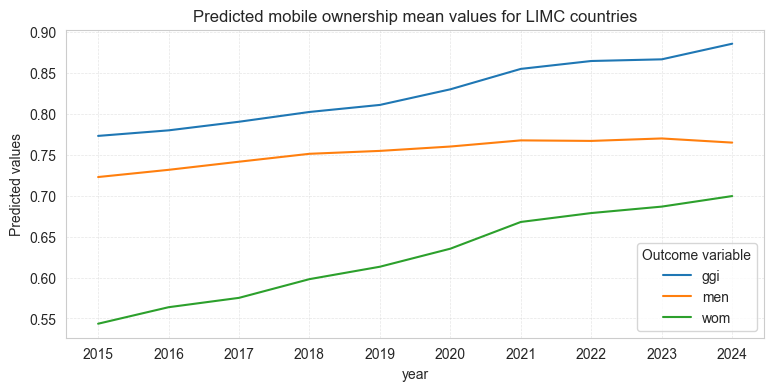

In [6]:
df_limc_mob = df_limc.loc[df_limc['indicator']=='mobile']
df_limc_int = df_limc.loc[df_limc['indicator']=='internet']
temp = df_limc_mob.groupby(['year','outcome_var']).agg({'pred':'mean'}).reset_index()

# visualize the results
fig, ax = plt.subplots(1,1, figsize=(9, 4))
sns.lineplot(data=temp, x='year', y='pred', hue='outcome_var', ax=ax)
ax.set_ylabel('Predicted values')
ax.set_xticks(temp['year'].unique())
ax.legend(title='Outcome variable',loc='lower right')
ax.set_title('Predicted mobile ownership mean values for LIMC countries')
ax.grid(axis='both', linestyle='--', alpha=0.5, linewidth=0.5)

/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_9111/3625007479.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


[Text(0, 0, 'Sub-Saharan Africa'),
 Text(1, 0, 'Southern Asia'),
 Text(2, 0, 'Latin America and the Caribbean'),
 Text(3, 0, 'Northern Africa'),
 Text(4, 0, 'Western Asia'),
 Text(5, 0, 'South-eastern Asia'),
 Text(6, 0, 'Micronesia'),
 Text(7, 0, 'Eastern Asia'),
 Text(8, 0, 'Melanesia'),
 Text(9, 0, 'Eastern Europe'),
 Text(10, 0, 'Central Asia'),
 Text(11, 0, 'Polynesia')]

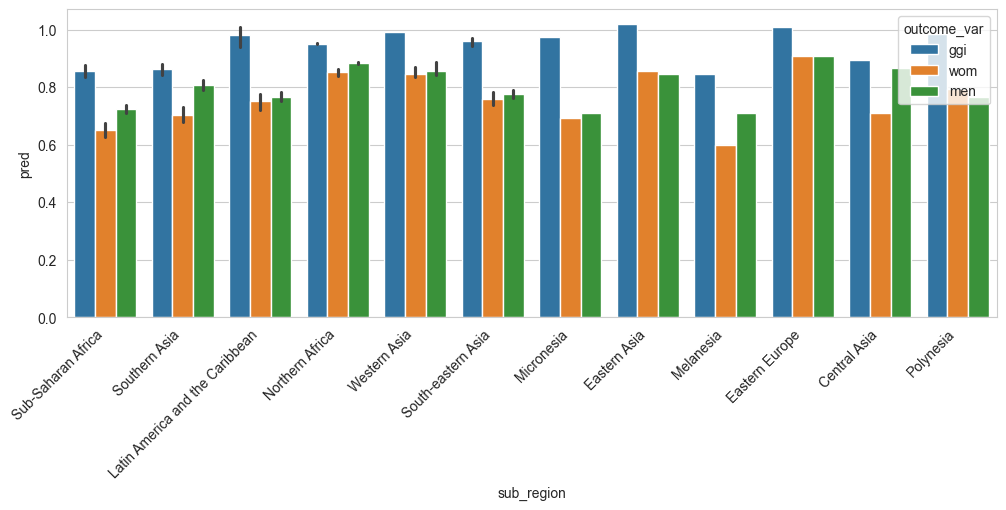

In [7]:
temp = df_limc_mob.loc[(df_limc_mob['year']==2024),]
temp.groupby(['sub_region','outcome_var']).agg({'pred':'mean'}).reset_index()

fig, ax = plt.subplots(1,1, figsize=(12, 4))
sns.barplot(data=temp, x='sub_region', y='pred', hue='outcome_var',ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.savefig(params.dropbox_data_path.parent / f'graphs/result_check/{}.pdf')

/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_9111/928658053.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


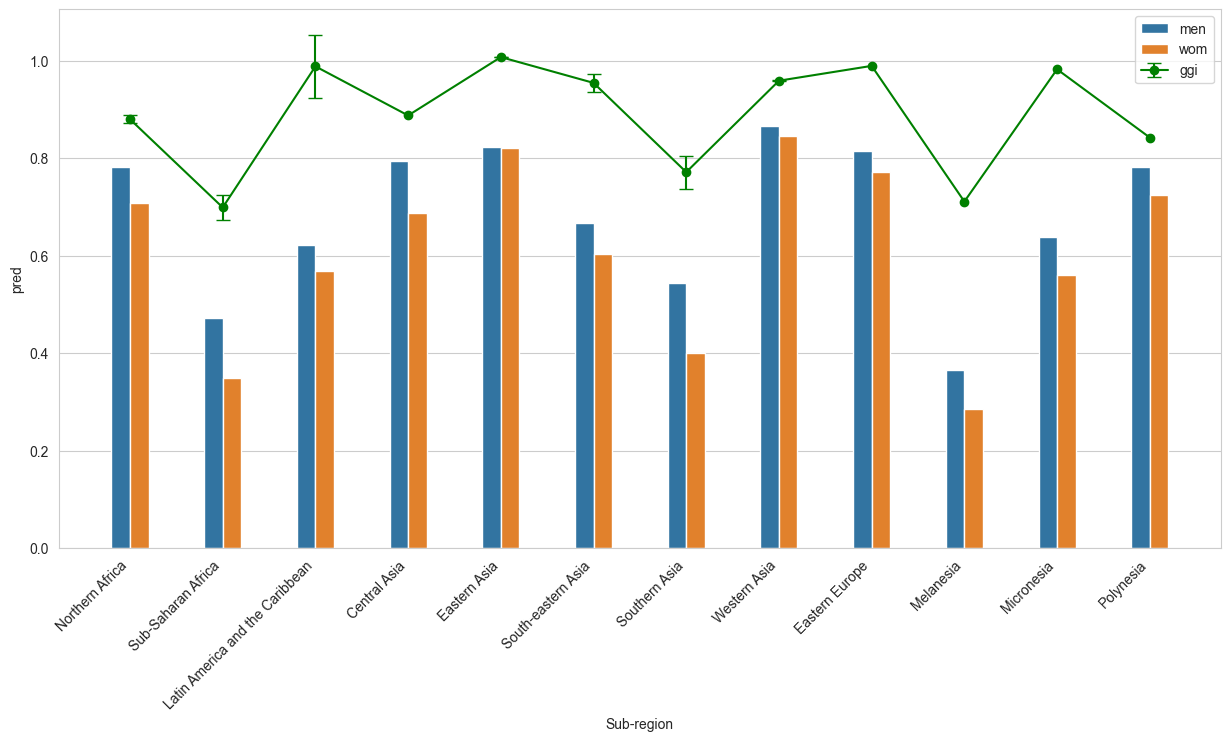

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the data for 2024
indicator = 'internet'
df_limc_selected = df_limc.loc[df_limc['indicator']==indicator]
temp = df_limc_selected.loc[(df_limc_selected['year'] == 2024),]

# Separate data for 'ggi' and other outcome_vars
temp_bar = temp[temp['outcome_var'] != 'ggi']
temp_line = temp[temp['outcome_var'] == 'ggi']

# Group data and calculate mean prediction for barplot (excluding 'ggi')
grouped_bar_data = temp_bar.groupby(['sub_region', 'outcome_var']).agg({'pred': 'mean'}).reset_index()

# Group data and calculate mean and confidence interval for 'ggi'
ggi_mean = temp_line.groupby('sub_region').agg(
    pred_mean=('pred', 'mean'),
    pred_ci_low=('pred', lambda x: x.mean() - 1.96 * (x.std() / len(x) ** 0.5)),
    pred_ci_high=('pred', lambda x: x.mean() + 1.96 * (x.std() / len(x) ** 0.5))
).reset_index()

# Create a custom order for 'sub_region' based on 'region'
sub_region_order = temp.groupby('sub_region')['region'].first().sort_values().index

# Set 'sub_region' as a categorical variable with the defined order
grouped_bar_data['sub_region'] = pd.Categorical(grouped_bar_data['sub_region'], categories=sub_region_order, ordered=True)
ggi_mean['sub_region'] = pd.Categorical(ggi_mean['sub_region'], categories=sub_region_order, ordered=True)

# Sort the data according to the custom order
grouped_bar_data = grouped_bar_data.sort_values('sub_region')
ggi_mean = ggi_mean.sort_values('sub_region')

# Create figure and axes
fig, ax = plt.subplots(1, 1, figsize=(15, 7))

# Plot bars for all outcome_var except 'ggi'
sns.barplot(data=grouped_bar_data, x='sub_region', y='pred', hue='outcome_var', ax=ax,width=0.4)

# Plot line for the mean of 'ggi' with confidence interval
ax.errorbar(
    x=ggi_mean['sub_region'],
    y=ggi_mean['pred_mean'],
    yerr=[ggi_mean['pred_mean'] - ggi_mean['pred_ci_low'], ggi_mean['pred_ci_high'] - ggi_mean['pred_mean']],
    fmt='o-', color='green', label='ggi', capsize=5
)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# Set x-axis label
ax.set_xlabel('Sub-region')

# Add legend
ax.legend()

# Save the figure
plt.savefig(params.dropbox_data_path.parent / f'graphs/result_check/mean_predicted_{indicator}_ownership_LIMC_2024_by_sub_regions.pdf')



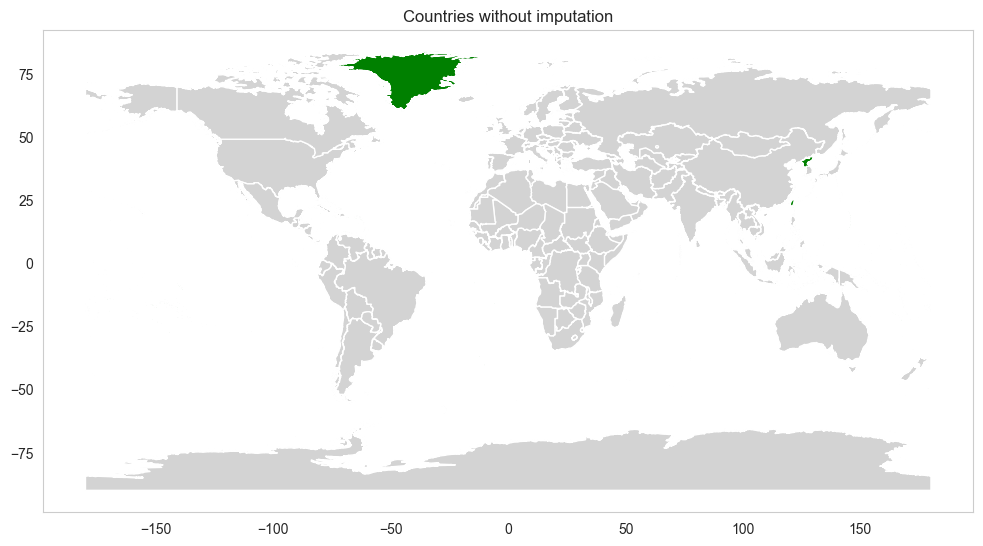

In [61]:
import geopandas as gpd
import matplotlib.pyplot as plt

# List of ISO3 codes
iso3_list = params.countries_to_exclude_for_imputation['mobile']

# Load the high-resolution shapefile (change the path to where you downloaded the file)
world = gpd.read_file(params.dropbox_data_path/"ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")

# Filter the world dataframe to include only the countries with ISO3 codes in iso3_list
selected_countries = world[world['ISO_A3'].isin(iso3_list)]

# Create a figure and axis for the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.grid(alpha=0)
# Plot the world map
world.plot(ax=ax, color='lightgray')

# Plot the selected countries
selected_countries.plot(ax=ax, color='green')

# Set title and display the plot
plt.title('Countries without imputation')
plt.savefig(params.dropbox_data_path.parent / 'graphs/result_check/un_imputed_countries.pdf')


# missing imputation check

In [7]:

df_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:
    for outcome_var in ['wom', 'men', 'ggi']:

        data_path = params.dropbox_data_path / f"combined_data/{indicator}"
        dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
        df = pd.read_csv(data_path / dataset)
        df = df.dropna(subset=params.bg_cols+params.fb_vars)
        df_to_predict = df.loc[df[f'{indicator}_{outcome_var}'].notnull()]

        model_filename = f'{indicator}_combined_{indicator}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / 'models/rf' / model_filename

        # load the model
        model = load_model(model_filepath)
        df_predict_results = pd.DataFrame(columns=['outcome_var','model_type','iso3', 'year', 'true', 'pred'])

        X = preprocess_data(df_to_predict[model_specs['combined']])
        countries = df_to_predict['iso3'].tolist()
        years = df_to_predict[f'{indicator}_year'].tolist()
        true_values = df_to_predict[f'{indicator}_{outcome_var}'].tolist()
        y_pred = model.predict(X)

        for ind in range(len(y_pred)):
            df_predict_results.loc[len(df_predict_results), :] = [f'{indicator}_{outcome_var}','combined',countries[ind], years[ind], true_values[ind], y_pred[ind]]

        df_res = pd.concat([df_res, df_predict_results], axis=0)

    # df_res.drop(columns=['year'], inplace=True)
    # df_res.rename(columns={f'{indicator}_year': 'year'}, inplace=True)
# df_res.to_csv(params.dropbox_data_path.parent/'results/random_forest_most_recent_aligned_results.csv', index=False)




In [8]:
countries_internet = params.countries_to_exclude_for_imputation['internet']
countries_mobile = params.countries_to_exclude_for_imputation['mobile']
df_res_selected = df_res.loc[df_res['iso3'].isin(countries_internet)]


,outcome_var,model_type,iso3,year,true,pred
40,internet_wom,combined,CUW,2017.0,0.710073,0.766666
69,internet_wom,combined,HKG,2022.0,0.949628,0.889798
103,internet_wom,combined,MAC,2021.0,0.890887,0.855158
138,internet_wom,combined,PRI,2021.0,0.865289,0.847252
141,internet_wom,combined,PSE,2022.0,0.885633,0.827948
161,internet_wom,combined,TCA,2019.0,0.924961,0.866568
171,internet_wom,combined,TWN,2022.0,0.85019,0.832379
179,internet_wom,combined,VGB,2017.0,0.807542,0.805683
183,internet_wom,combined,XKX,2018.0,0.906648,0.896476
40,internet_men,combined,CUW,2017.0,0.696862,0.754261


In [15]:
df_res_selected.loc[df_res_selected['outcome_var'].str.contains('ggi')][['year','iso3','outcome_var']].value_counts()

year    iso3  outcome_var 
2017.0  CUW   internet_ggi    1
              mobile_ggi      1
        VGB   internet_ggi    1
              mobile_ggi      1
2018.0  XKX   internet_ggi    1
2019.0  MAC   mobile_ggi      1
        TCA   internet_ggi    1
              mobile_ggi      1
2021.0  MAC   internet_ggi    1
        PRI   internet_ggi    1
2022.0  HKG   internet_ggi    1
              mobile_ggi      1
        PSE   internet_ggi    1
              mobile_ggi      1
        TWN   internet_ggi    1
              mobile_ggi      1
dtype: int64

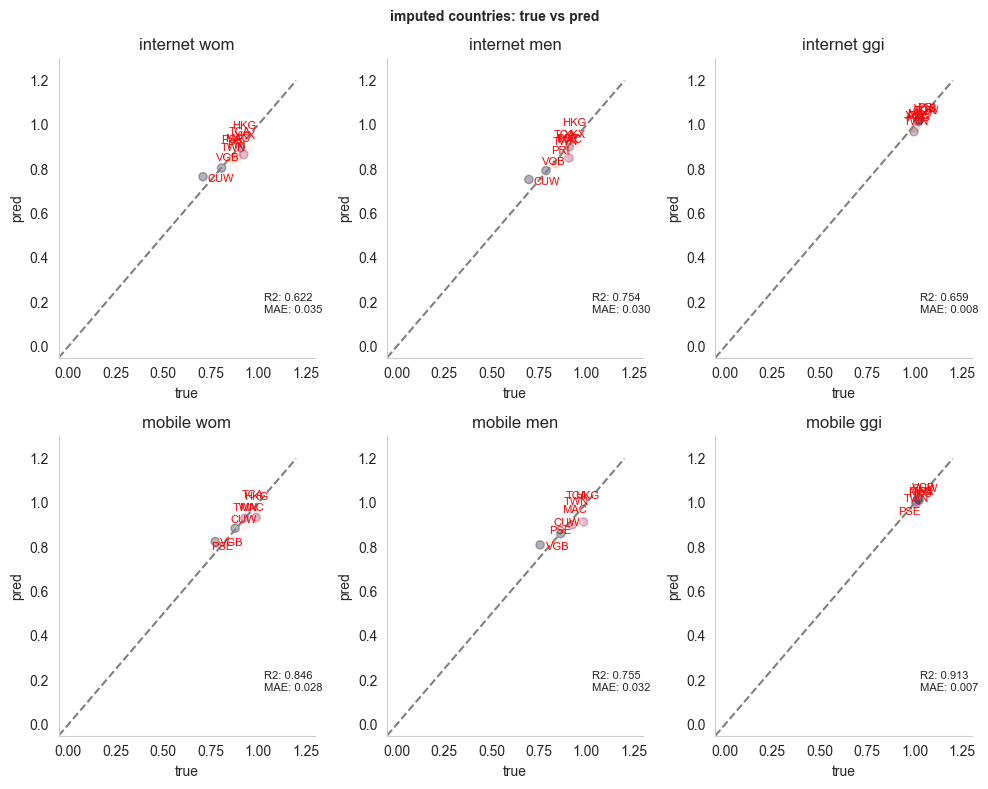

In [14]:

countries_internet = params.countries_to_exclude_for_imputation['internet']
countries_mobile = params.countries_to_exclude_for_imputation['mobile']

df_res_selected = df_res.loc[df_res['iso3'].isin(countries_internet)]


from sklearn.metrics import r2_score, mean_absolute_error
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
axes = axes.flatten()
for ind,outcome_var in enumerate(df_res_selected.outcome_var.unique()):
    df_res_selected_outcome = df_res_selected.loc[df_res_selected['outcome_var'] == outcome_var]

    ax = axes[ind]
    ax.scatter(df_res_selected_outcome['true'], df_res_selected_outcome['pred'], c=df_res_selected_outcome['year'], alpha=0.3)
    r2, mae = r2_score(df_res_selected_outcome['true'], df_res_selected_outcome['pred']), mean_absolute_error(df_res_selected_outcome['true'], df_res_selected_outcome['pred'])
    ax.set_xlabel('true')
    ax.set_ylabel(f'pred')
    ax.set_title(f'{outcome_var.replace("_"," ")}')
    plt.tight_layout()
    x_min = -0.05
    y_max = 1.3
    ax.set_xlim(x_min, y_max)
    ax.set_ylim(x_min, y_max)
    ax.text(0.8, 0.15, f'R2: {r2:.3f}\nMAE: {mae:.3f}', transform=ax.transAxes, fontsize=8)

    for i, row_data in df_res_selected_outcome.iterrows():
        ax.annotate(row_data['iso3'], (row_data['pred'], row_data['true']),
                              textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8, color='red')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
    ax.grid(axis='both', linestyle='--', alpha=0)

fig.suptitle('imputed countries: true vs pred', fontsize=10, fontweight='bold')
fig.tight_layout()
plt.show()
